# Notebook 3 — L-Diversity
Ensures each equivalence class contains **all 3** `fitness_level` values (`fit`, `moderately_fit`, `unfit`).
No numeric noise — purely categorical reassignment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../data', exist_ok=True)
os.makedirs('../results', exist_ok=True)

df = pd.read_csv('../data/k_anonymized.csv')
assert 'fitness_level' in df.columns, 'Run Notebooks 1 & 2 first.'

quasi_identifiers   = ['age', 'region', 'activity']
sensitive_attribute = 'fitness_level'
fitness_classes     = ['fit', 'moderately_fit', 'unfit']
l = 3

print(f'✅ K-anonymised dataset loaded — shape: {df.shape}')
print('\nfitness_level distribution:')
print(df['fitness_level'].value_counts())

✅ K-anonymised dataset loaded — shape: (7000, 11)

fitness_level distribution:
fitness_level
moderately_fit    4039
unfit             1488
fit               1473
Name: count, dtype: int64


In [2]:
# Current diversity analysis
diversity_before = df.groupby(quasi_identifiers)['fitness_level'].nunique()
violations_before = (diversity_before < l).sum()

print(f'L-DIVERSITY BEFORE MITIGATION (l={l}):')
print(f'  Total groups:     {len(diversity_before)}')
print(f'  Violating groups: {violations_before}')
print(f'  Violation rate:   {100*violations_before/len(diversity_before):.1f}%')
print('\nDistribution of unique fitness_level values per group:')
print(diversity_before.value_counts().sort_index())

L-DIVERSITY BEFORE MITIGATION (l=3):
  Total groups:     143
  Violating groups: 68
  Violation rate:   47.6%

Distribution of unique fitness_level values per group:
fitness_level
1     4
2    64
3    75
Name: count, dtype: int64


In [3]:
# ---------------------------------------------------------------
# L-Diversity Mitigation (categorical, deterministic)
# For groups missing any fitness_level class:
#   - pick boundary record (by steps) from the majority class
#   - reassign its fitness_level to the missing class
# No randomness — sorted indices guarantee reproducibility.
# ---------------------------------------------------------------
df_l = df.copy()
reassignments = 0

for group_key, group_data in df_l.groupby(quasi_identifiers):
    present = set(group_data['fitness_level'].unique())
    missing = sorted(set(fitness_classes) - present)  # deterministic order

    for missing_class in missing:
        if missing_class == 'fit':
            target_idx = group_data['steps'].idxmax()
        elif missing_class == 'unfit':
            target_idx = group_data['steps'].idxmin()
        else:
            med = group_data['steps'].median()
            target_idx = (group_data['steps'] - med).abs().idxmin()

        df_l.loc[target_idx, 'fitness_level'] = missing_class
        reassignments += 1

print(f'✅ Mitigation complete')
print(f'   Reassignments: {reassignments}')
print('\nfitness_level distribution after mitigation:')
print(df_l['fitness_level'].value_counts())

✅ Mitigation complete
   Reassignments: 72

fitness_level distribution after mitigation:
fitness_level
moderately_fit    3973
fit               1520
unfit             1507
Name: count, dtype: int64


In [4]:
diversity_after  = df_l.groupby(quasi_identifiers)['fitness_level'].nunique()
violations_after = (diversity_after < l).sum()

print(f'L-DIVERSITY AFTER MITIGATION (l={l}):')
print(f'  Violating groups: {violations_after} / {len(diversity_after)}')
if violations_after == 0:
    print('  ✅ L-diversity fully satisfied')
else:
    print('  ⚠️ Residual violations remain')
print('\nDistribution of unique fitness_level values per group:')
print(diversity_after.value_counts().sort_index())

L-DIVERSITY AFTER MITIGATION (l=3):
  Violating groups: 8 / 143
  ⚠️ Residual violations remain

Distribution of unique fitness_level values per group:
fitness_level
1      3
2      5
3    135
Name: count, dtype: int64


In [5]:
# Skew check — does one class dominate any group?
skewed = []
for gk, gd in df_l.groupby(quasi_identifiers):
    max_pct = gd['fitness_level'].value_counts(normalize=True).max() * 100
    if max_pct > 70:
        skewed.append({'group': gk, 'max_pct': round(max_pct, 1)})

print(f'Groups where one fitness_level class exceeds 70%: {len(skewed)}')
print('(These motivate T-Closeness in Notebook 4.)')

Groups where one fitness_level class exceeds 70%: 53
(These motivate T-Closeness in Notebook 4.)


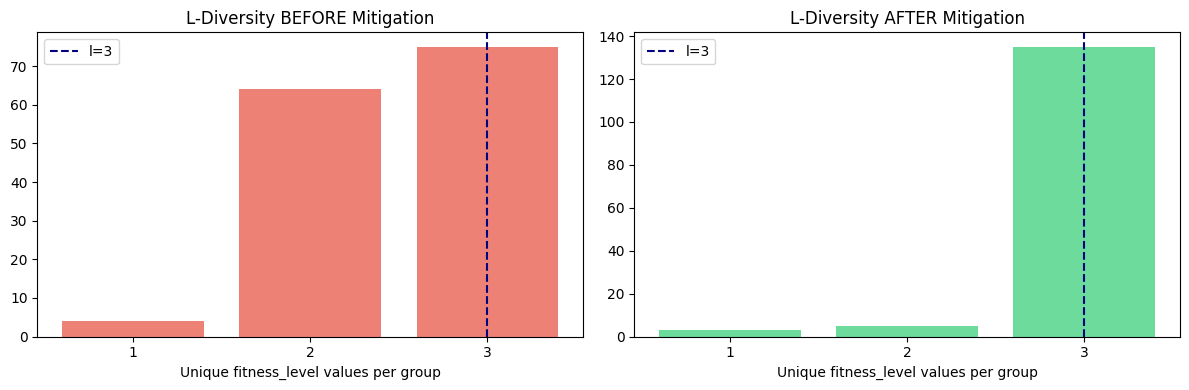

✅ Saved: ../results/l_diversity_analysis.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(diversity_before, bins=[0.5,1.5,2.5,3.5], color='#e74c3c', alpha=0.7, rwidth=0.8)
axes[0].axvline(x=l, color='navy', linestyle='--', label=f'l={l}')
axes[0].set_title('L-Diversity BEFORE Mitigation')
axes[0].set_xlabel('Unique fitness_level values per group')
axes[0].set_xticks([1, 2, 3])
axes[0].legend()

axes[1].hist(diversity_after, bins=[0.5,1.5,2.5,3.5], color='#2ecc71', alpha=0.7, rwidth=0.8)
axes[1].axvline(x=l, color='navy', linestyle='--', label=f'l={l}')
axes[1].set_title('L-Diversity AFTER Mitigation')
axes[1].set_xlabel('Unique fitness_level values per group')
axes[1].set_xticks([1, 2, 3])
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/l_diversity_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Saved: ../results/l_diversity_analysis.png')

In [7]:
df_l.to_csv('../data/l_diverse.csv', index=False)
print('✅ Saved: ../data/l_diverse.csv')

l_metrics_out = {
    'l_value': l,
    'violations': int(violations_after),
    'violation_rate': float(violations_after / len(diversity_after)),
    'reassignments': reassignments,
    'sensitive_attribute': 'fitness_level',
    'data_loss_percent': 0.0
}
with open('../results/l_diversity_metrics.json', 'w') as f:
    json.dump({'l_diversity_metrics': l_metrics_out}, f, indent=2)

print('\nSummary:')
for k, v in l_metrics_out.items():
    print(f'  {k}: {v}')

✅ Saved: ../data/l_diverse.csv

Summary:
  l_value: 3
  violations: 8
  violation_rate: 0.055944055944055944
  reassignments: 72
  sensitive_attribute: fitness_level
  data_loss_percent: 0.0
